# 01 Â· Exploratory Data Analysis

**MuleShield AI â€” SIH26184 (MHA / I4C)**

What the corpus contains, how the laundering chains are shaped, and â€” most
importantly â€” a check that no single feature gives the label away.

The dataset is **synthetic**. Real NCRP transaction data is legally restricted,
so the ledger is generated by `scripts/generate_data.py` from documented
laundering typology (layering, fund-splitting, many-to-one pooling). What that
means for the claims in this project is spelled out at the end of the notebook.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

# Works whether the kernel starts in notebooks/ or at the project root.
ROOT = Path.cwd()
while not (ROOT / "engine").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "engine"))

DATA = ROOT / "data"
MODELS = ROOT / "models"

# The published numbers. Everything below is checked against this file.
METRICS = json.loads((DATA / "metrics.json").read_text())

def check(label, got, expected, tol=5e-3):
    """Print whether a freshly computed figure matches the published one."""
    ok = abs(float(got) - float(expected)) <= tol
    print(f"  {'MATCH   ' if ok else 'MISMATCH'}  {label:38s} "
          f"notebook={float(got):.4f}  published={float(expected):.4f}")
    return ok

print("project root :", ROOT)
print("metrics from :", METRICS["_about"][:60], "...")

project root : D:\SIH 2026\SIHPROJECT2
metrics from : Measured figures for MuleShield AI (SIH26184). Written by th ...


## 1 Â· What is in the corpus

In [2]:
txn   = pd.read_csv(DATA / "transactions.csv", low_memory=False)
node  = pd.read_csv(DATA / "node_features.csv")
comp  = pd.read_csv(DATA / "victim_complaints.csv")
atm   = pd.read_csv(DATA / "atm_directory.csv")

print(f"transactions   {len(txn):>8,}")
print(f"accounts       {len(node):>8,}")
print(f"complaints     {len(comp):>8,}")
print(f"ATMs           {len(atm):>8,}")
print()
print(f"fraud txns     {int((txn.is_fraud == 1).sum()):>8,}")
print(f"terminal txns  {int((txn.is_terminal == 1).sum()):>8,}   <- cash-out events")
print(f"labelled mules {int(node.is_mule_label.sum()):>8,}   "
      f"({100 * node.is_mule_label.mean():.2f}% prevalence)")

transactions    622,188
accounts         49,999
complaints        2,500
ATMs              1,000

fraud txns       22,201
terminal txns     6,426   <- cash-out events
labelled mules    1,476   (2.95% prevalence)


Prevalence of ~3% matters more than it looks. It is why F1 at a 0.5 threshold is
a poor summary and why the detector ships with a tuned threshold â€” a point the
detection notebook returns to.

## 2 Â· Shape of a laundering chain

,transfers,median_amount,terminal
hop_depth,,,
1,4975,48135.17,0
2,9955,15258.16,0
3,6426,16227.54,5581
4,845,16671.54,845


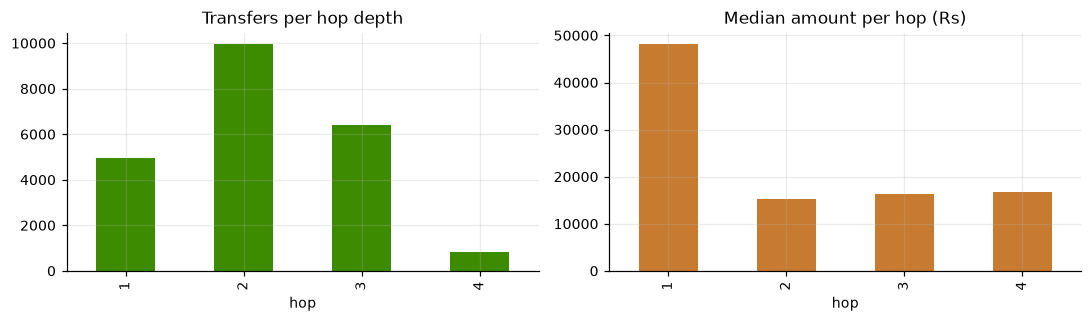

In [3]:
fraud = txn[txn.is_fraud == 1]

hop = fraud.groupby("hop_depth").agg(
    transfers=("txn_id", "count"),
    median_amount=("amount", "median"),
    terminal=("is_terminal", "sum"),
)
display(hop)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
hop["transfers"].plot(kind="bar", ax=ax[0], color="#3d8b00")
ax[0].set_title("Transfers per hop depth"); ax[0].set_xlabel("hop")

hop["median_amount"].plot(kind="bar", ax=ax[1], color="#c77b30")
ax[1].set_title("Median amount per hop (Rs)"); ax[1].set_xlabel("hop")
plt.tight_layout(); plt.show()

Amounts fall with depth because each mule keeps a cut (the generator's
`passthrough` trait). Transfers rise then fall as chains fan out and then pool
into shared terminal accounts.

In [4]:
# Fan-out: how many destinations does one account send to inside a chain?
fan = fraud.groupby(["complaint_id", "src_account"]).size()
print("Fan-out per sending account within a chain")
print(fan.value_counts().sort_index().head(6).to_string())

# Convergence: many-to-one pooling onto a shared terminal
term = fraud[fraud.is_terminal == 1]
conv = term.groupby(["complaint_id", "dst_account"]).size()
print(f"\nTerminal accounts fed by 3+ sources: "
      f"{int((conv >= 3).sum()):,} of {len(conv):,} "
      f"({100 * (conv >= 3).mean():.1f}%)")

Fan-out per sending account within a chain
1    9744
2    2495
3    2469
4      15

Terminal accounts fed by 3+ sources: 1,040 of 3,657 (28.4%)


## 3 Â· The cash-out delay is bimodal, on purpose

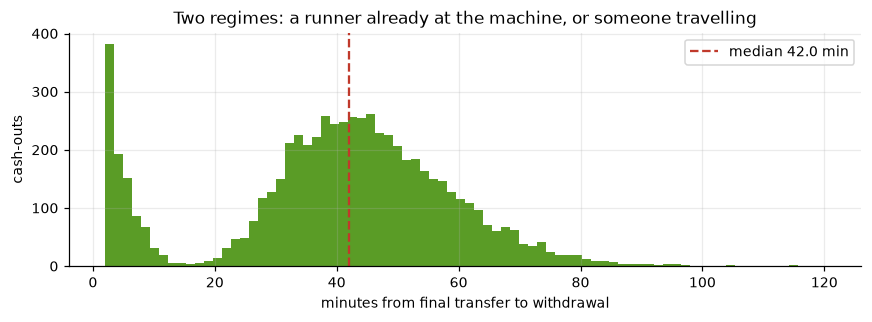

count    6426.00
mean       40.16
std        19.11
min         2.00
25%        31.80
50%        41.97
75%        52.34
max       120.16


In [5]:
delay = txn.loc[txn.is_terminal == 1, "time_to_cashout_min"].dropna()

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(delay, bins=80, color="#3d8b00", alpha=0.85)
ax.axvline(delay.median(), color="#c0392b", ls="--",
           label=f"median {delay.median():.1f} min")
ax.set_xlabel("minutes from final transfer to withdrawal")
ax.set_ylabel("cash-outs"); ax.legend()
ax.set_title("Two regimes: a runner already at the machine, or someone travelling")
plt.tight_layout(); plt.show()

print(delay.describe().round(2).to_string())

The left mode is a crew with a runner already standing at the ATM; the right mode
is travel time. This was a deliberate modelling decision â€” a single-regime delay
with a ~22-minute floor never produces an urgent case, which would make any
"did we have time to act?" metric trivially 100% and hide exactly the cases the
system exists to catch.

## 4 Â· Distance decay â€” the criminology the ranker relies on

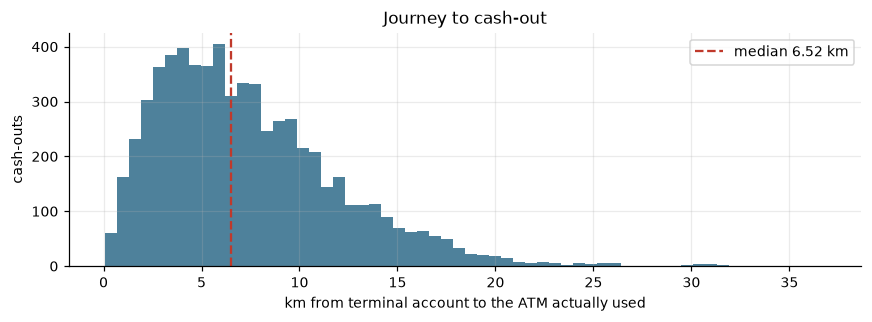

median 6.52 km   mean 7.42 km   90th pct 13.72 km


In [6]:
import math

def hav(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlam = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

cash = txn[(txn.is_terminal == 1) & txn.cashout_atm_id.notna()].copy()
loc = node.set_index("account_id")[["lat", "long"]]
atm_loc = atm.set_index("atm_id")[["lat", "long"]]

j = cash.join(loc, on="dst_account", rsuffix="_acc").join(atm_loc, on="cashout_atm_id", rsuffix="_atm")
j = j.dropna(subset=["lat", "lat_atm"])
d = hav(j["lat"].values, j["long"].values, j["lat_atm"].values, j["long_atm"].values)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(d, bins=60, color="#2f6b8a", alpha=0.85)
ax.axvline(np.median(d), color="#c0392b", ls="--", label=f"median {np.median(d):.2f} km")
ax.set_xlabel("km from terminal account to the ATM actually used")
ax.set_ylabel("cash-outs"); ax.legend()
ax.set_title("Journey to cash-out")
plt.tight_layout(); plt.show()

print(f"median {np.median(d):.2f} km   mean {d.mean():.2f} km   90th pct {np.percentile(d, 90):.2f} km")

Offence probability falling off with distance from an anchor point is one of the
most robust findings in environmental criminology (Brantingham & Brantingham's
crime pattern theory; the journey-to-crime literature). The generator encodes it
as `exp(-d / 5 km)` and the ranker's first feature is exactly that term.

## 5 Â· The leakage check â€” does any single feature give the label away?

This is the section that matters most for credibility. An earlier build of this
dataset had three construction artefacts that made detection far too easy; the
worst of them let one feature separate the classes at **AUC 0.96 on its own**.
They were found, removed, and the headline F1 was re-measured *downward* from an
invalid 0.9386 to 0.8955.

If any feature below scores near 1.0, the dataset is broken again.

In [7]:
from sklearn.metrics import roc_auc_score
from gnn_model import FEATURE_COLS, derive_features

nd = derive_features(node)
y = nd["is_mule_label"].to_numpy()

rows = []
for col in FEATURE_COLS:
    v = nd[col].astype(float).to_numpy()
    auc = roc_auc_score(y, v)
    rows.append((col, max(auc, 1 - auc)))   # direction-agnostic

auc_df = (pd.DataFrame(rows, columns=["feature", "standalone_auc"])
            .sort_values("standalone_auc", ascending=False)
            .reset_index(drop=True))
display(auc_df.style.background_gradient(subset=["standalone_auc"], cmap="Oranges"))

worst = auc_df.standalone_auc.max()
top = auc_df.iloc[0]

# The red line is the DOCUMENTED artefact level, not a round number picked here.
# Before the generator was repaired, "this account has almost no ordinary banking
# history" separated the classes at AUC 0.96 on its own (OVERNIGHT_ML_AUDIT.md,
# artefact A1). That is the state this check exists to detect a return to.
ARTEFACT_AUC = 0.96

print(f"strongest single feature : {top.feature} at {worst:.4f} AUC")
print(f"documented artefact level: {ARTEFACT_AUC:.4f} (pre-fix state)")
print("VERDICT:", "OK - below the artefact level" if worst < ARTEFACT_AUC
      else "PROBLEM - the data has regressed to the pre-fix state")

,feature,standalone_auc
0,txn_count_24h,0.902098
1,burst_out_5min,0.901450
2,activity_per_day,0.856080
3,night_txn_ratio,0.770459
4,dwell_log,0.758338
5,median_dwell_seconds,0.758338
6,total_received,0.695973
7,account_age_days,0.678096
8,counterparty_concentration,0.677056
9,avg_txn_amount,0.648076


strongest single feature : txn_count_24h at 0.9021 AUC
documented artefact level: 0.9600 (pre-fix state)
VERDICT: OK - below the artefact level


`txn_count_24h` and `burst_out_5min` sit around **0.90 AUC**, which looks alarming
until you separate two different questions.

**AUC asks "does this feature rank accounts well?"** â€” and yes, it does, because a
mule genuinely *is* an account that transacts in rapid bursts. That is the real
behavioural phenomenon the detector is supposed to key on, not an artefact.

**F1 asks "can this feature classify accounts on its own?"** â€” and at 2.95%
prevalence the answer is no. The cell below measures it directly. A feature that
truly gave the label away would score highly on both.

In [8]:
from sklearn.metrics import f1_score

# Best achievable F1 from a single threshold on the strongest feature.
v = nd[top.feature].astype(float).to_numpy()
best = 0.0
for t in np.percentile(v, np.linspace(1, 99, 200)):
    for sign in (1, -1):
        pred = ((v > t) if sign == 1 else (v <= t)).astype(int)
        if 0 < pred.sum() < len(pred):
            best = max(best, f1_score(y, pred, zero_division=0))

print(f"{top.feature}")
print(f"  ranks well          : AUC {worst:.4f}")
print(f"  classifies poorly   : best single-threshold F1 {best:.4f}")
print(f"  random forest (all 15 features) reaches F1 "
      f"{METRICS['detection_baselines']['best_non_graph']:.4f}")
print(f"  GraphSAGE reaches F1 {METRICS['detection']['test_f1']:.4f}")
print()
print("A single feature that solved the task would push the numbers below it")
print("toward 1.0. It does not, so the signal is real but far from sufficient -")
print("which is exactly the regime a detector should be operating in.")

txn_count_24h
  ranks well          : AUC 0.9021
  classifies poorly   : best single-threshold F1 0.4700
  random forest (all 15 features) reaches F1 0.8565
  GraphSAGE reaches F1 0.9050

A single feature that solved the task would push the numbers below it
toward 1.0. It does not, so the signal is real but far from sufficient -
which is exactly the regime a detector should be operating in.


## 6 Â· Feature correlation

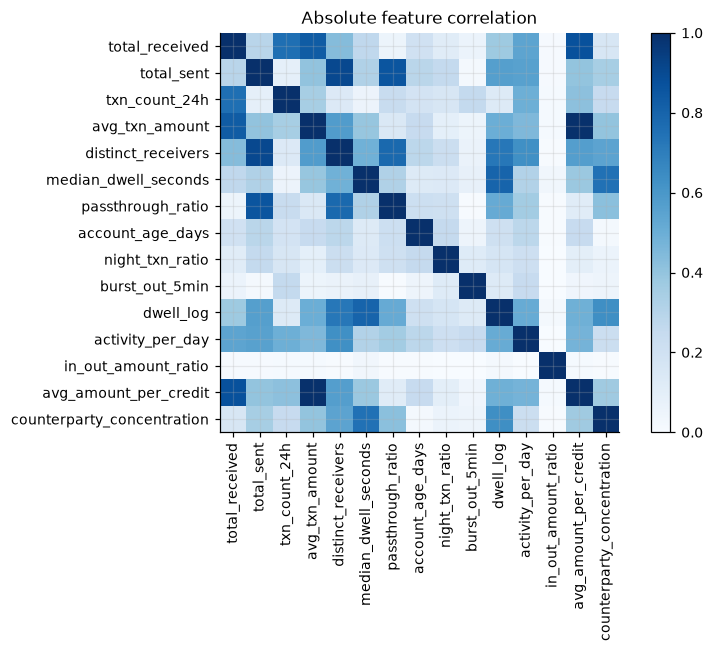

Pairs above r = 0.90: [('total_sent', 'distinct_receivers', np.float64(0.9059203571644348)), ('avg_txn_amount', 'avg_amount_per_credit', np.float64(0.9946003851142707))]


In [9]:
corr = nd[FEATURE_COLS].corr().abs()

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS))); ax.set_xticklabels(FEATURE_COLS, rotation=90)
ax.set_yticks(range(len(FEATURE_COLS))); ax.set_yticklabels(FEATURE_COLS)
plt.colorbar(im, fraction=0.046)
ax.set_title("Absolute feature correlation")
plt.tight_layout(); plt.show()

hi = [(FEATURE_COLS[i], FEATURE_COLS[j], corr.iloc[i, j])
      for i in range(len(FEATURE_COLS)) for j in range(i + 1, len(FEATURE_COLS))
      if corr.iloc[i, j] > 0.9]
print("Pairs above r = 0.90:", hi if hi else "none")

Near-duplicate columns were already dropped during feature selection
(`in_degree` was r = 1.000 with `txn_count_24h` â€” literally the same column
twice). `lat`/`long` were dropped as pure noise: mules are spread across all 79
cities, so coordinates carry no signal about whether an account is one.

## 7 Â· Mule vs clean, feature by feature

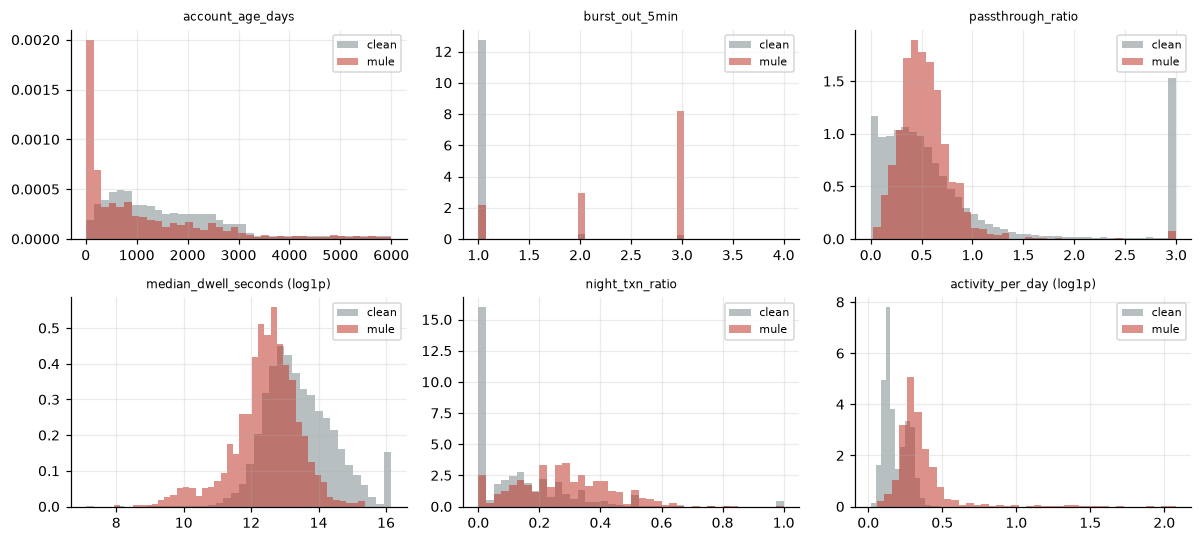

In [10]:
show = ["account_age_days", "burst_out_5min", "passthrough_ratio",
        "median_dwell_seconds", "night_txn_ratio", "activity_per_day"]

fig, axes = plt.subplots(2, 3, figsize=(11, 5))
for ax, col in zip(axes.ravel(), show):
    for lab, colr, name in [(0, "#7f8c8d", "clean"), (1, "#c0392b", "mule")]:
        v = nd.loc[nd.is_mule_label == lab, col].astype(float)
        v = v[np.isfinite(v)]
        if col in ("median_dwell_seconds", "activity_per_day"):
            v = np.log1p(v)
        ax.hist(v, bins=40, alpha=0.55, density=True, color=colr, label=name)
    ax.set_title(col + (" (log1p)" if col in ("median_dwell_seconds", "activity_per_day") else ""),
                 fontsize=8)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

The distributions **overlap**. That is the intended state â€” separable classes
would mean the task is trivial and the reported scores meaningless.

## What this dataset does and does not license us to claim

**Structure is defensible.** Layering, fund-splitting and many-to-one pooling are
documented FATF/RBI laundering typologies. Distance decay is established
criminology. RBI's own MuleHunter.AI is built on 19 enumerated behavioural
patterns, which is itself evidence that such patterns are real and enumerable.

**Parameter values are chosen, not estimated.** The decay length (5 km), the
surveillance-risk weight (2.0), the same-bank boost (2.0) and the crew-preference
boost (9.0) are design constants. Nobody measured that Indian mule crews prefer
own-bank ATMs by a factor of exactly two.

**Therefore:** the synthetic corpus validates the *method*, not the *performance*.
Every score in the notebooks that follow is a real measurement on this generative
process. None of them is a prediction about what the system would score in Delhi.
What transfers to real data is the architecture, the relative comparisons, and the
code â€” not the absolute numbers.